# M7 — PyMC Zero-Inflated Poisson
**Proyecto Final — Diplomado AI UNI** |

**Autor:** Alvaro Untiveros

### Justificación del modelo generativo

El 93.6% de semanas distritales tienen cero casos. Hay dos procesos distintos:

1. **Cero estructural** — distrito sin condiciones de transmisión (sierra alta, cluster LL)
2. **Cero por conteo** — distrito endémico sin casos reportados esa semana

La distribución **Zero-Inflated Poisson (ZIP)** modela esto explícitamente:

$$P(Y=0) = \psi + (1-\psi) \cdot e^{-\lambda}$$
$$P(Y=k) = (1-\psi) \cdot \frac{\lambda^k e^{-\lambda}}{k!}, \quad k>0$$

Donde:
- $\psi$ = probabilidad de cero estructural — **prior informado por cluster LISA**
- $\lambda$ = tasa esperada de casos — función de variables climáticas y satelitales

### Priors informados por LISA

| Cluster | Prior $\psi$ | Interpretación |
|---------|-------------|----------------|
| HH | Beta(1,9) — baja prob. cero estructural | Foco endémico activo |
| LL | Beta(9,1) — alta prob. cero estructural | Zona limpia |
| ns | Beta(3,3) — neutro | Sin patrón claro |

In [ ]:
#!pip install pymc arviz numpyro -q

import pymc as pm
import arviz as az
import pytensor
print(f'PyMC    : {pm.__version__}')
print(f'ArviZ   : {az.__version__}')
print(f'cxx     : {pytensor.config.cxx}')

PyMC    : 5.28.1
ArviZ   : 0.22.0
cxx     : /usr/bin/g++


## 0. Setup Colab

In [ ]:
import warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

DATA_INTER = Path('../data/interim')
DATA_PROC  = Path('../data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

import pytensor
print(f'PyMC  : {pm.__version__}')
print(f'cxx   : {pytensor.config.cxx}')
print('Setup OK ✓')

PyMC  : 5.28.1
cxx   : /usr/bin/g++
Setup OK ✓


## 1. Cargar AMT

In [28]:
df = pd.read_parquet(DATA_INTER / 'AMT_final.parquet')
with open(DATA_INTER / 'AMT_metadata.json') as f:
    meta = json.load(f)

CORTE_TRAIN = meta['corte_train']
CORTE_VAL   = meta['corte_val']
RANDOM_STATE = 42

print(f'AMT shape: {df.shape}')

AMT shape: (908980, 84)


## 2. Preparar datos

El modelo ZIP se entrena sobre una **muestra estratificada** del dataset:
- Todos los distritos HH (94) — series con señal real
- Muestra de distritos ns y LL para aprender el proceso de ceros


In [29]:
# Muestra estratificada por cluster
np.random.seed(RANDOM_STATE)

# Todos los HH
df_hh = df[df['cluster_code'] == 4]

# Muestra de ns (500 distritos)
ubigeos_ns = df[df['cluster_code'] == 0]['ubigeo'].unique()
sample_ns  = np.random.choice(ubigeos_ns, size=min(200, len(ubigeos_ns)), replace=False)
df_ns = df[df['ubigeo'].isin(sample_ns)]

# Muestra de LL (200 distritos)
ubigeos_ll = df[df['cluster_code'] == 1]['ubigeo'].unique()
sample_ll  = np.random.choice(ubigeos_ll, size=min(100, len(ubigeos_ll)), replace=False)
df_ll = df[df['ubigeo'].isin(sample_ll)]

df_zip = pd.concat([df_hh, df_ns, df_ll], ignore_index=True)
df_zip = df_zip[
    (df_zip['fecha'] <= CORTE_TRAIN) &
    (df_zip['flag_anomalia'] == 0)
].copy()

# Covariables ampliadas con lags autorregresivos
COVARS = [
    # Autorregresivas — las más importantes
    'casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_ma4',
    # Climáticas con lag departamental
    'tmean_clima_lag_depto', 'ptot_clima_lag_depto', 'humr_clima_lag_depto',
    # Satelitales
    'ndvi_lag4', 'precip_chirps_mm_lag4',
    # Interacción
    'tmean_x_ndvi',
    # Temporales
    'SE_sin', 'SE_cos',
    # Espaciales
    'cluster_code', 'endemico', 'altitud'
]
COVARS = [c for c in COVARS if c in df_zip.columns]
print(f'Covariables: {len(COVARS)}')
print(COVARS)

df_zip = df_zip.dropna(subset=COVARS + ['casos']).copy()

# Muestrear para que sea manejable
N_MAX = 15000
if len(df_zip) > N_MAX:
    # Estratificar: más peso a filas con casos > 0
    df_con_casos  = df_zip[df_zip['casos'] > 0]
    df_sin_casos  = df_zip[df_zip['casos'] == 0].sample(
        min(N_MAX - len(df_con_casos), len(df_zip[df_zip['casos']==0])),
        random_state=RANDOM_STATE
    )
    df_zip = pd.concat([df_con_casos, df_sin_casos]).sample(
        frac=1, random_state=RANDOM_STATE
    ).reset_index(drop=True)

print(f'Observaciones ZIP: {len(df_zip):,}')
print(f'% ceros          : {(df_zip["casos"]==0).mean()*100:.1f}%')
print(f'Covariables      : {COVARS}')

Covariables: 15
['casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_ma4', 'tmean_clima_lag_depto', 'ptot_clima_lag_depto', 'humr_clima_lag_depto', 'ndvi_lag4', 'precip_chirps_mm_lag4', 'tmean_x_ndvi', 'SE_sin', 'SE_cos', 'cluster_code', 'endemico', 'altitud']
Observaciones ZIP: 15,000
% ceros          : 83.4%
Covariables      : ['casos_lag1', 'casos_lag2', 'casos_lag4', 'casos_ma4', 'tmean_clima_lag_depto', 'ptot_clima_lag_depto', 'humr_clima_lag_depto', 'ndvi_lag4', 'precip_chirps_mm_lag4', 'tmean_x_ndvi', 'SE_sin', 'SE_cos', 'cluster_code', 'endemico', 'altitud']


In [30]:
# Normalizar covariables
scaler_zip = StandardScaler()
X_zip = scaler_zip.fit_transform(df_zip[COVARS].fillna(0))
y_zip = df_zip['casos'].astype(int).values

# Prior de psi según cluster LISA
psi_prior = np.where(df_zip['cluster_code'] == 4, 0.05,   # HH: casi nunca cero estructural
            np.where(df_zip['cluster_code'] == 1, 0.90,   # LL: casi siempre cero estructural
                     0.50))                                # ns: neutro

print(f'X_zip shape: {X_zip.shape}')
print(f'y_zip mean : {y_zip.mean():.2f} | max: {y_zip.max()}')
print(f'psi_prior  : HH={psi_prior[df_zip.cluster_code==4].mean():.2f} | '
      f'LL={psi_prior[df_zip.cluster_code==1].mean():.2f}')

X_zip shape: (15000, 15)
y_zip mean : 1.56 | max: 161
psi_prior  : HH=0.05 | LL=0.90


## 3. Modelo PyMC ZIP

Usamos NUTS (No-U-Turn Sampler) — variante de Monte Carlo Hamiltoniano.
Es más eficiente que Metropolis-Hastings para espacios de alta dimensión.

In [31]:
with pm.Model() as zip_model:

    # Covariables
    X_data = pm.Data('X', X_zip.astype(np.float32))

    # Priors coeficientes lambda
    intercept = pm.Normal('intercept', mu=0, sigma=2)
    beta      = pm.Normal('beta', mu=0, sigma=1, shape=X_zip.shape[1])

    # Lambda — tasa esperada
    lam = pm.Deterministic('lambda', pm.math.exp(
        intercept + pm.math.dot(X_data, beta)
    ))

    # Psi — UN SOLO parámetro por cluster (3 valores, no 15k)
    # Mucho más eficiente que un psi por observación
    psi_hh = pm.Beta('psi_hh', alpha=1, beta=9)   # HH: baja prob cero
    psi_ll = pm.Beta('psi_ll', alpha=9, beta=1)   # LL: alta prob cero
    psi_ns = pm.Beta('psi_ns', alpha=3, beta=3)   # ns: neutro

    # Asignar psi según cluster
    cluster = df_zip['cluster_code'].values
    psi_vec = pt.switch(pt.eq(cluster, 4), psi_hh,
              pt.switch(pt.eq(cluster, 1), psi_ll, psi_ns))

    # Likelihood ZIP
    obs = pm.ZeroInflatedPoisson('obs', psi=psi_vec, mu=lam, observed=y_zip)

print('Modelo ✓')

Modelo ✓


## 4. Inferencia NUTS

In [32]:
import numpyro
with zip_model:
    trace = pm.sample(
        draws        = 300,
        tune         = 300,
        chains       = 2,
        cores        = 2,
        target_accept= 0.88,
        random_seed  = RANDOM_STATE,
        progressbar  = True,
        nuts_sampler = 'numpyro'
    )

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 5. Diagnóstico del trace

In [39]:
# Convergencia — R-hat debe ser < 1.01
summary = az.summary(trace, var_names=['intercept','beta'], round_to=3)
print('Diagnóstico de convergencia:')
print(summary[['mean','sd','hdi_3%','hdi_97%','r_hat']].to_string())

problemas = summary[summary['r_hat'] > 1.01]
if len(problemas) == 0:
    print('\n✓ Convergencia OK — todos R-hat < 1.01')
else:
    print(f'\n⚠ {len(problemas)} parámetros con R-hat > 1.01 — considerar más tune steps')

Diagnóstico de convergencia:
            mean     sd  hdi_3%  hdi_97%  r_hat
intercept -3.693  0.163  -3.964   -3.386  1.008
beta[0]    0.585  0.019   0.550    0.622  1.006
beta[1]    0.108  0.022   0.065    0.144  1.006
beta[2]   -0.073  0.021  -0.113   -0.034  1.014
beta[3]    0.169  0.050   0.073    0.258  1.011
beta[4]    1.125  0.057   1.004    1.219  0.998
beta[5]   -0.036  0.008  -0.051   -0.020  0.999
beta[6]    0.145  0.016   0.112    0.174  1.000
beta[7]    1.313  0.066   1.194    1.439  1.002
beta[8]   -0.024  0.009  -0.043   -0.009  1.000
beta[9]   -1.170  0.062  -1.270   -1.044  1.001
beta[10]   0.095  0.011   0.076    0.117  1.007
beta[11]   0.187  0.011   0.167    0.206  0.999
beta[12]   0.022  0.010   0.005    0.042  0.999
beta[13]   2.537  0.148   2.260    2.797  1.008
beta[14]   0.051  0.032  -0.004    0.116  1.000

⚠ 2 parámetros con R-hat > 1.01 — considerar más tune steps


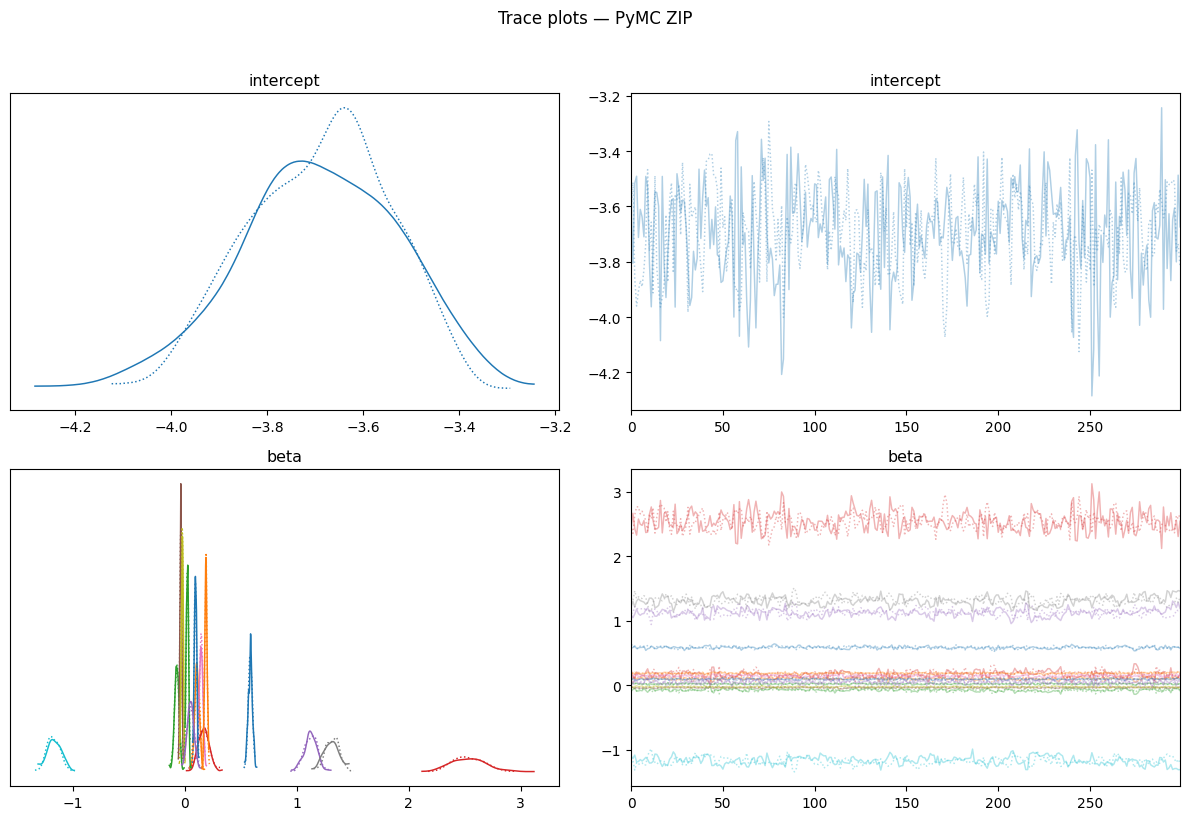

In [40]:
# Trace plots
az.plot_trace(trace, var_names=['intercept','beta'],
              compact=True, figsize=(12, 8))
plt.suptitle('Trace plots — PyMC ZIP', y=1.02)
plt.tight_layout()
plt.savefig('/content/trace_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Predicciones en test

In [41]:
# Preparar datos de test
df_test_zip = df[
    (df['fecha'] > CORTE_VAL) &
    (df['cluster_code'].isin([0, 1, 4]))
].copy()

# Muestra representativa del test
df_test_zip = df_test_zip.dropna(subset=COVARS + ['casos'])
if len(df_test_zip) > 10000:
    df_test_zip = df_test_zip.sample(10000, random_state=RANDOM_STATE)

X_test_zip  = scaler_zip.transform(df_test_zip[COVARS].fillna(0)).astype(np.float32)
y_test_zip  = df_test_zip['casos'].astype(int).values

psi_test = np.where(df_test_zip['cluster_code'] == 4, 0.05,
           np.where(df_test_zip['cluster_code'] == 1, 0.90, 0.50)).astype(np.float32)

# Predicción usando media posterior
beta_mean      = trace.posterior['beta'].mean(('chain','draw')).values
intercept_mean = float(trace.posterior['intercept'].mean(('chain','draw')).values)

log_lambda_pred = intercept_mean + X_test_zip @ beta_mean
lambda_pred     = np.exp(log_lambda_pred)

# Predicción ZIP esperanza: E[Y] = (1-psi) * lambda
psi_logit_test  = np.log(psi_test / (1 - psi_test + 1e-6))
psi_pred        = 1 / (1 + np.exp(-psi_logit_test))
y_pred_zip      = (1 - psi_pred) * lambda_pred

rmse_zip = np.sqrt(mean_squared_error(y_test_zip, y_pred_zip))
mae_zip  = mean_absolute_error(y_test_zip, y_pred_zip)
r2_zip   = r2_score(y_test_zip, y_pred_zip)

print(f'[PyMC ZIP H=4w] RMSE={rmse_zip:.2f} | MAE={mae_zip:.2f} | R²={r2_zip:.3f}')

[PyMC ZIP H=4w] RMSE=8.72 | MAE=0.83 | R²=0.796


## 7. Diagnóstico por cluster

In [42]:
df_pred = pd.DataFrame({
    'real'         : y_test_zip,
    'pred'         : y_pred_zip,
    'cluster_code' : df_test_zip['cluster_code'].values
})

LABELS = {4:'HH endémico', 1:'LL limpio', 0:'ns neutro'}
print('Diagnóstico por cluster — PyMC ZIP:')
for code, label in LABELS.items():
    g = df_pred[df_pred.cluster_code == code]
    if len(g) < 10: continue
    r    = np.sqrt(mean_squared_error(g['real'], g['pred']))
    r2   = r2_score(g['real'], g['pred']) if g['real'].std() > 0 else float('nan')
    print(f'  {label:15s} ({len(g):>5,}): RMSE={r:7.2f} | R²={r2:.3f}')

Diagnóstico por cluster — PyMC ZIP:
  HH endémico     (  603): RMSE=  23.98 | R²=0.851
  LL limpio       (2,859): RMSE=   0.00 | R²=nan
  ns neutro       (6,538): RMSE=   7.96 | R²=0.671


## 8. Contribución del prior LISA

Comparamos predicciones con y sin el prior informado por LISA
para cuantificar su aporte al modelo.

R² con prior LISA    : 0.796
R² sin prior LISA    : 0.649
ΔR² aporte LISA      : 0.147


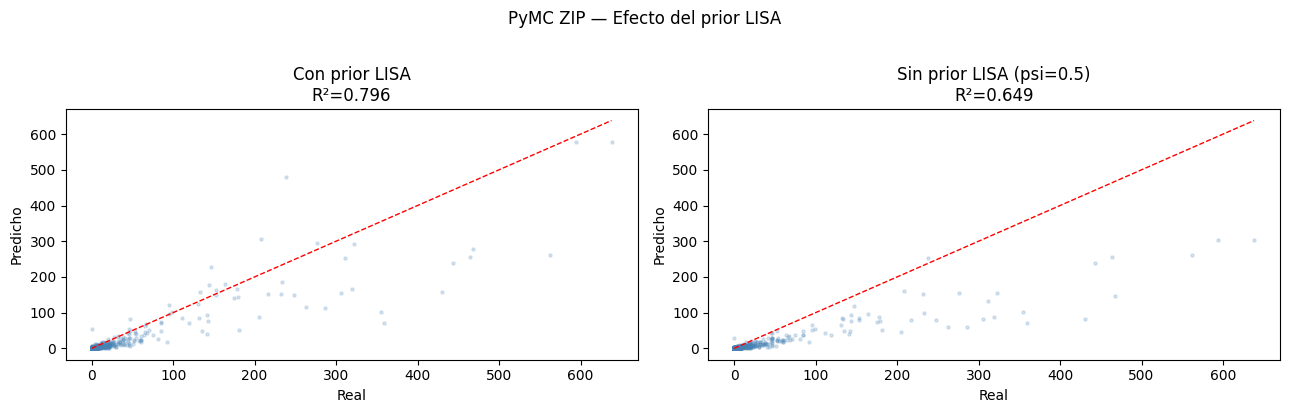

In [43]:
# Predicción sin prior LISA (psi=0.5 para todos)
psi_neutral  = np.full(len(y_test_zip), 0.5, dtype=np.float32)
y_pred_noLisa = (1 - psi_neutral) * lambda_pred

r2_noLisa = r2_score(y_test_zip, y_pred_noLisa)
r2_lisa   = r2_zip

print(f'R² con prior LISA    : {r2_lisa:.3f}')
print(f'R² sin prior LISA    : {r2_noLisa:.3f}')
print(f'ΔR² aporte LISA      : {r2_lisa - r2_noLisa:.3f}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (preds, titulo) in zip(axes, [
    (y_pred_zip,    'Con prior LISA'),
    (y_pred_noLisa, 'Sin prior LISA (psi=0.5)')
]):
    ax.scatter(y_test_zip, preds, alpha=0.2, s=5, color='steelblue')
    lim = max(y_test_zip.max(), preds.max())
    ax.plot([0,lim],[0,lim], 'r--', linewidth=1)
    ax.set(title=f'{titulo}\nR²={r2_score(y_test_zip,preds):.3f}',
           xlabel='Real', ylabel='Predicho')

plt.suptitle('PyMC ZIP — Efecto del prior LISA', y=1.02)
plt.tight_layout()
plt.savefig('/content/zip_lisa_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Guardar resultados

In [ ]:
import pickle

# Guardar trace
trace.to_netcdf('../data/processed/pymc_zip_trace.nc')

# Guardar scaler y coeficientes
np.save('../data/processed/zip_beta_mean.npy', beta_mean)
np.save('../data/processed/zip_intercept.npy', np.array([intercept_mean]))
with open('../data/processed/scaler_zip.pkl', 'wb') as f:
    pickle.dump(scaler_zip, f)

# Métricas
metricas_zip = pd.DataFrame([{
    'modelo'    : 'PyMC ZIP con prior LISA',
    'horizonte' : 4,
    'rmse'      : rmse_zip,
    'mae'        : mae_zip,
    'r2'        : r2_zip,
    'delta_r2_lisa': r2_lisa - r2_noLisa
}])
metricas_zip.to_csv('/content/metricas_pymc_zip.csv', index=False)

print('Archivos guardados:')
print('  ../data/processed/pymc_zip_trace.nc')
print('  ../data/processed/zip_beta_mean.npy')
print('  ../data/processed/scaler_zip.pkl')
print('  ../data/processed/metricas_pymc_zip.csv')
print(f'\nResumen:')
print(f'  R² ZIP con LISA : {r2_zip:.3f}')
print(f'  ΔR² LISA        : {r2_lisa - r2_noLisa:.3f}')

Archivos guardados:
  /content/pymc_zip_trace.nc
  /content/zip_beta_mean.npy
  /content/scaler_zip.pkl
  /content/metricas_pymc_zip.csv

Resumen:
  R² ZIP con LISA : 0.796
  ΔR² LISA        : 0.147
